In [22]:
import os
import time
import torch
import random
import librosa
import torchaudio
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, recall_score, f1_score


RCNN combines CNN and RNNS i.e., LSTM or GRU
It is designed for sequential data where CNN extracts spatial features and the RNN learns temporal patterns.



In [2]:
df=pd.read_csv('/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/metadata_handover.csv')

In [3]:
base_path='/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/audio_files'


In [4]:
audio_data = {}  

for _, row in df.iterrows():
    file_path = os.path.join(base_path, row['file_id'])
    
    if os.path.exists(file_path):
        y, sr = librosa.load(file_path, sr=16000)
        audio_data[row['file_id']] = {'waveform': y, 'sr': sr}
    else:
        print("Missing file:", file_path)

In [5]:
def pad_audio(waveform,sr=16000,min_duration=1.5):
    """Pad short audio files with 0 ensuring uniform length"""
    target_size=int(sr* min_duration)
    if(len(waveform)<target_size):
        waveform=np.pad(waveform,(0,target_size-len(y)))
    return y,sr

In [6]:
def flatten_waveform(y):
    """
    Convert any nested structure (list, tuple, np.ndarray) to flat 1D float32 array
    """
    flat_list = []

    def _flatten(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for sub in item:
                _flatten(sub)
        else:
            flat_list.append(float(item))

    _flatten(y)
    return np.array(flat_list, dtype=np.float32)

In [7]:
TARGET_SR = 16000
TARGET_DURATION = 1.5
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def process_audio(waveform, sr):

    waveform = np.asarray(waveform, dtype=np.float32).flatten()

    if sr != TARGET_SR:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR

    if len(waveform) < TARGET_LENGTH:
        waveform = np.pad(waveform, (0, TARGET_LENGTH - len(waveform)))
    else:
        waveform = waveform[:TARGET_LENGTH]

    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-6)

    return log_mel.astype(np.float32)

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df['label'])

X = []
y_labels = []

for _, row in df.iterrows():
    file_id = row['file_id']
    label_str = row['label']

    if file_id in audio_data:
        y = audio_data[file_id]['waveform']
        sr = audio_data[file_id]['sr']


        y = flatten_waveform(y)

        if y.size == 0:
            print(f"Skipping empty waveform: {file_id}")
            continue


        label_int = label_encoder.transform([label_str])[0]
        label_tensor = torch.tensor(label_int, dtype=torch.long)


        mel = process_audio(y, sr)
        mel = np.expand_dims(mel, axis=0)

        mel_tensor = torch.tensor(mel, dtype=torch.float32)

        X.append(mel_tensor)
        y_labels.append(label_tensor)



In [9]:
X = torch.stack(X)          # shape: [N, 1, 128, frames]
y_labels = torch.stack(y_labels)  # shape: [N]

In [10]:
X.shape

torch.Size([1211, 1, 128, 47])

In [11]:
print(y_labels.shape)
print(X.shape)

torch.Size([1211])
torch.Size([1211, 1, 128, 47])


In [12]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_labels,
    test_size=0.3,
    stratify=y_labels,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,   
    stratify=y_temp,
    random_state=42
)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True      
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False     
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False     
)

/tmp/ipykernel_250/2906681264.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_train, dtype=torch.float32),
/tmp/ipykernel_250/2906681264.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_250/2906681264.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_val, dtype=torch.float32),
/tmp/ipykernel_250/2906681264.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().r

In [14]:
for batch_X, batch_y in train_loader:
    print(batch_X.shape)  # [32, 1, 128, 47]
    print(batch_y.shape)  # [32]
    break

torch.Size([32, 1, 128, 47])
torch.Size([32])


In [15]:
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        # CNN part
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.dropout=nn.Dropout(0.3)

        # RNN part
        self.rnn = nn.LSTM(
            input_size=64 * 32, 
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # Classification
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        # x shape: (batch, channels, freq, time)
        b, c, f, t = x.size()

        # reshape for RNN
        x = x.permute(0, 3, 1, 2)  # (batch, time, channels, freq)
        x = x.contiguous().view(b, t, c * f)
        x=self.dropout(x)
        x, _ = self.rnn(x)

        # Take last time step
        x = x[:, -1, :]

        x = self.fc(x)

        return x

In [16]:
from sklearn.utils.class_weight import compute_class_weight


y_numpy = y_labels.numpy()  # shape [num_samples]


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_numpy),
    y=y_numpy
)


class_weights = torch.tensor(class_weights, dtype=torch.float32)

print(class_weights)

tensor([2.3288, 0.8410, 0.6040, 1.8211, 0.8498])


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
num_epochs = 50
train_losses = []
val_losses = []
val_recalls = []
val_f1s = []
best_val_loss = float('inf')
patience = 10
counter = 0


start_train = time.perf_counter()

for epoch in range(num_epochs):
    # Training 
    model.train()
    total_train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    val_preds = []
    val_true = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
            
            val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            val_true.extend(targets.cpu().numpy())
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss = avg_val_loss
    val_recall = recall_score(val_true, val_preds, average='weighted', zero_division=0)
    val_f1 = f1_score(val_true, val_preds, average='weighted', zero_division=0)
    
    val_losses.append(avg_val_loss)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Recall: {val_recall:.4f} | "
          f"Val F1: {val_f1:.4f}")
    
    # Early stopping based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
    
    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break


end_train = time.perf_counter()
training_time = end_train - start_train
print(f"\nTotal Training Time: {training_time:.2f} seconds")


Epoch [1/50] Train Loss: 1.3990 | Val Loss: 1.2009 | Val Recall: 0.5440 | Val F1: 0.4892
Epoch [2/50] Train Loss: 1.1769 | Val Loss: 0.9988 | Val Recall: 0.6319 | Val F1: 0.6376
Epoch [3/50] Train Loss: 1.0319 | Val Loss: 0.8943 | Val Recall: 0.6978 | Val F1: 0.6925
Epoch [4/50] Train Loss: 0.9417 | Val Loss: 0.8611 | Val Recall: 0.6813 | Val F1: 0.6917
Epoch [5/50] Train Loss: 0.8810 | Val Loss: 0.8017 | Val Recall: 0.6703 | Val F1: 0.6655
Epoch [6/50] Train Loss: 0.8292 | Val Loss: 0.7500 | Val Recall: 0.7198 | Val F1: 0.7310
Epoch [7/50] Train Loss: 0.7607 | Val Loss: 0.6565 | Val Recall: 0.7692 | Val F1: 0.7672
Epoch [8/50] Train Loss: 0.6615 | Val Loss: 0.6031 | Val Recall: 0.7912 | Val F1: 0.7905
Epoch [9/50] Train Loss: 0.5982 | Val Loss: 0.5554 | Val Recall: 0.8022 | Val F1: 0.8039
Epoch [10/50] Train Loss: 0.5403 | Val Loss: 0.5468 | Val Recall: 0.7967 | Val F1: 0.7989
Epoch [11/50] Train Loss: 0.5498 | Val Loss: 0.5715 | Val Recall: 0.7692 | Val F1: 0.7795
Epoch [12/50] Train

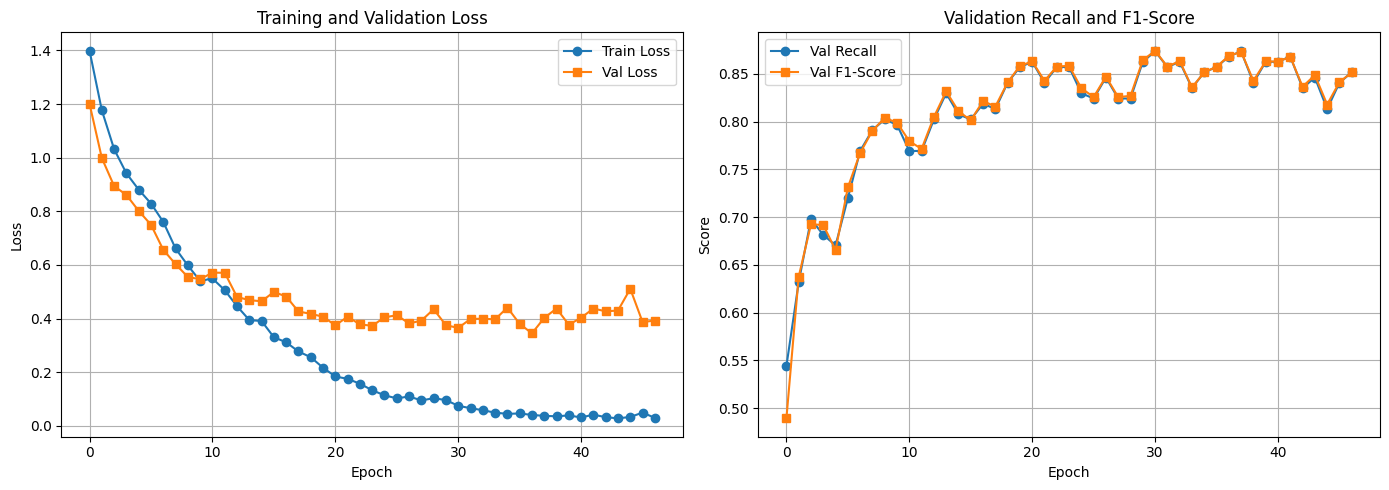


 Best model saved to 'best_model.pth'
 Training metrics plot saved to 'training_metrics.png'


In [19]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Recall and F1 curves
axes[1].plot(val_recalls, label='Val Recall', marker='o')
axes[1].plot(val_f1s, label='Val F1-Score', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Recall and F1-Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Best model saved to 'best_model.pth'")
print(f" Training metrics plot saved to 'training_metrics.png'")

In [20]:
# Evaluation

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        test_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        test_true.extend(targets.cpu().numpy())

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Test Recall (weighted): {recall_score(test_true, test_preds, average='weighted'):.4f}")
print(f"Test F1-Score (weighted): {f1_score(test_true, test_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_preds, 
                          target_names=['Asthma', 'Bronchitis', 'COPD', 'Healthy', 'Pneumonia']))



TEST SET RESULTS
Test Recall (weighted): 0.8571
Test F1-Score (weighted): 0.8556

Classification Report:
              precision    recall  f1-score   support

      Asthma       0.94      0.94      0.94        16
  Bronchitis       0.82      0.77      0.80        43
        COPD       0.88      0.95      0.91        60
     Healthy       0.81      0.85      0.83        20
   Pneumonia       0.85      0.79      0.82        43

    accuracy                           0.86       182
   macro avg       0.86      0.86      0.86       182
weighted avg       0.86      0.86      0.86       182



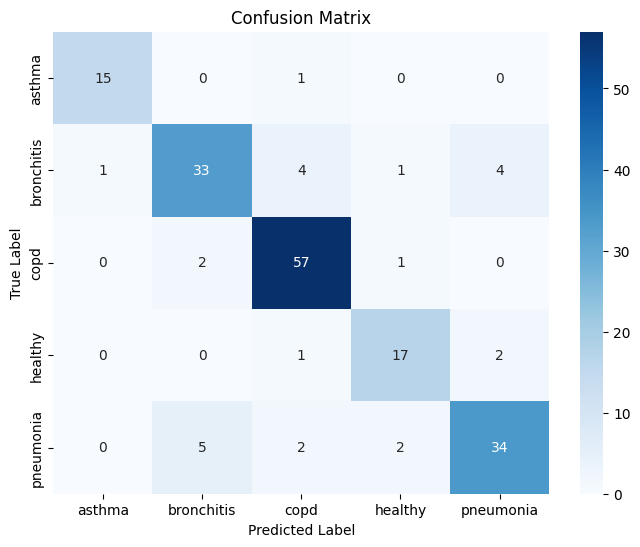

In [23]:
# Confusion matrix
cm = confusion_matrix(test_true, test_preds, labels=[0,1,2,3,4])

class_names = ['asthma', 'bronchitis', 'copd', 'healthy', 'pneumonia']


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
